# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')

import importlib
import functions  # First import
importlib.reload(functions)  # Reloads the module to reflect changes
from functions import *  # Now import functions.py

In [ ]:
#add_custom_fonts(loc=".myfonts")
import subprocess
from shadow.plot import *
from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

In [3]:
filtered_palnt_b = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_b_nox.pkl')
filtered_palnt_c = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_c_nox.pkl')
filtered_palnt_d = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_d_co.pkl')

In [ ]:
db0 = pd.read_csv('/media/m3rg2000/mounted/Junaid/.../Emissions/Old emission/db0_kiln.csv')
db0['Total cooling air'] = db0['Total cooling air']/1000
db0['CO2 content in the raw gas (preheater outlet)'] = db0['CO2 content in the raw gas (preheater outlet)']/1000
db0['CO content in the raw gas (preheater outlet)'] = db0['CO content in the raw gas (preheater outlet)']*10000

pp_description = pd.read_csv('/home/m3rg2000/Junaid_temporary/Data/db0_kiln_column_description.csv')
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
df_merged = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/df_merged.pkl')
df_filtered_quantile = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/filtered_quantile.pkl')
df_merged_Na_removed = df_merged.dropna(axis = 0, how = 'any', inplace = False)   
df_merged_Na_removed.drop(columns = ['timestamp', 'index_present_original'], inplace = True)


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


### Plant locations 

<AxesSubplot:>

<AxesSubplot:>

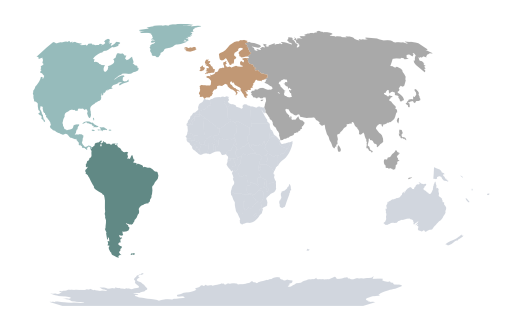

In [9]:
# -----------------------------------------------------
# Load Natural Earth shapefile
# -----------------------------------------------------
shapefile_path = "/home/m3rg2000/Junaid_temporary/Data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)

# Keep largest polygon only (cleaner appearance)
world['geometry'] = world['geometry'].apply(
    lambda geom: max(geom.geoms, key=lambda a: a.area)
    if isinstance(geom, MultiPolygon) else geom
)

# -----------------------------------------------------
# Reassign Russia to Asia (geographically defensible)
# -----------------------------------------------------
world.loc[world['ADMIN'] == 'Russia', 'CONTINENT'] = 'Asia'

# Robinson projection
world = world.to_crs('+proj=robin')

# -----------------------------------------------------
# Target countries
# -----------------------------------------------------
target_countries = [
    'India',
    'Italy',
    'United States of America',
    'Brazil'
]

continents_to_highlight = world.loc[
    world['ADMIN'].isin(target_countries),
    'CONTINENT'
].unique()

# -----------------------------------------------------
# Colors
# -----------------------------------------------------
highlight_colors = {
    'Asia': 'darkgrey',
    'Europe': '#C19875',
    'North America': '#96BBBB',
    'South America': '#618985'
}

# -----------------------------------------------------
# Split layers
# -----------------------------------------------------
highlighted = world[
    world['CONTINENT'].isin(continents_to_highlight)
].copy()

background = world[
    ~world['CONTINENT'].isin(continents_to_highlight)
]

# Dissolve to continent level
highlighted_dissolved = highlighted.dissolve(by='CONTINENT')

# -----------------------------------------------------
# Plot
# -----------------------------------------------------
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(13.77/2.54, 8.64/2.54))  # A5 size

background.plot(
    ax=ax,
    color='#8d99ae',
    edgecolor='none',
    alpha=0.4,
    zorder=1
)

highlighted_dissolved.plot(
    ax=ax,
    color=[highlight_colors[c] for c in highlighted_dissolved.index],
    edgecolor='none',
    linewidth=0,
    antialiased=True,
    zorder=2
)

ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    "/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/map_gray_light.pdf",
    bbox_inches='tight',
    transparent=True
)

plt.show()

### Process Parameter visualizaitons

### Plant A

In [5]:
un_reliable = ['Exit temperature from each preheater cyclone (Stage 5)',
'Flue gas outlet temperature (calciner outlet)',
'Flue gas O2 content (calciner outlet)',
'Clinker outlet temperature']
PP_all = list(db0.columns)
PP_reduced = [i for i in PP_all if i not in un_reliable]
PP_reduced.remove('timestamp')
len(PP_reduced)
pp_plant_A = df_filtered_quantile[PP_reduced]
pp_plant_A['Total cooling air'] = pp_plant_A['Total cooling air']/1000      #Scaling total cooling air
label_corr_A = [rf'$A_{{{i}}}$' for i in range(1, pp_plant_A.shape[1] + 1)]

short_names= [
    "Cyclone 1A Temp",
    "Cyclone 1B Temp",
    "Cyclone 2 Temp",
    "Cyclone 3 Temp",
    "Cyclone 4 Temp",
    "Preheater Gas Temp",
    "O₂ Preheater",
    "CO2",
    "NOx",
    "CO",
    "Raw Meal Temp",
    "Raw Meal Flow",
    "I Air Flow",
    "III Air Flow",
    "Kiln Inlet Temp",
    "Calciner Fuel",
    "Fuel Share",
    "O₂ Kiln Inlet",
    "Hot Meal Temp",
    "Kiln Fuel",
    "Cooling Air",
    "III Air Temp",
    "Clinker Prod",
    "GCT Gas Flow",
    "GCT Gas Temp",
    "GCT Spray Water",
    "GCT Outlet Temp",
    "Main Fan Gas Temp",
    "Fan Power",
    "Fan Speed",
    "Kiln Power",
    "Raw Mill Power",
    "Kiln Inlet Pres",
    "Precalciner Pres",
    "Cyclone 1A Pres",
    "Cyclone 1B Pres",
    "Cyclone 2 Pres",
    "Cyclone 3 Pres",
    "Cyclone 4 Pres",
    "Cyclone 5 Pres",
    "ID Fan Inlet Pres",
    "Mill Fan Pres 1",
    "Mill Fan Pres 2"
]

pp_plant_A.columns = short_names

43


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


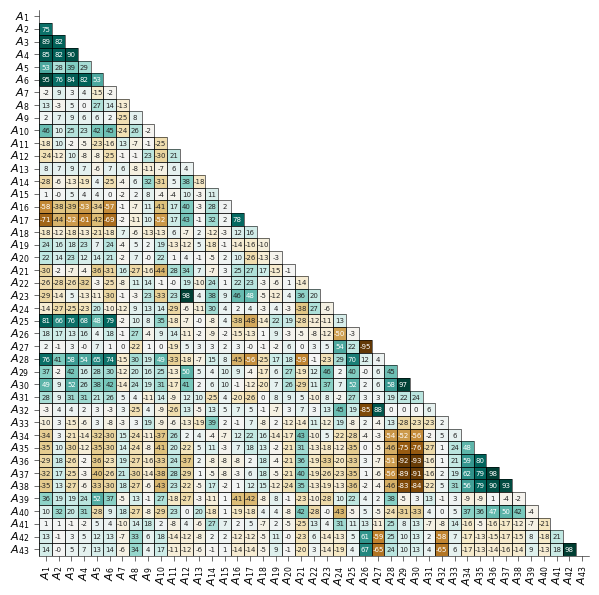

In [ ]:
line_width = 0.4
annot_size = 5
label_size = 8

corr_ = pp_plant_A.copy()
corr_.columns = label_corr_A
corr_df = corr_.corr(method='pearson')
corr_df_percent = corr_df * 100  # multiply by 100 for percentage scale

# Create mask to exclude upper triangle and diagonal
mask_ut = np.triu(np.ones(corr_df.shape), k=0)

# Plot heatmap for lower triangle only (excluding diagonal)
fig, ax = plt.subplots(figsize=(18/2.54, 18/2.54))

_ = sns.heatmap(corr_df_percent, mask=mask_ut.astype(bool), annot=True,
                cmap='BrBG', linewidth=0, linecolor='black',
                annot_kws={'size': annot_size, 'weight': 540, 'fontfamily': 'sans-serif'}, fmt='.0f', cbar=False, ax=ax, #weight
                vmin=-100, vmax=100)


# Set axis labels
n = len(label_corr_A)
_ = ax.set_xticks(np.arange(n) + 0.5)  # positions centered on each heatmap cell
_ = ax.set_yticks(np.arange(n) + 0.5)
_ = ax.set_xticklabels(label_corr_A, size=label_size, rotation = 90)
_ = ax.set_yticklabels(label_corr_A, size=label_size, rotation = 0)

# Draw inner gridlines only for lower triangle (excluding diagonal)
n = corr_df_percent.shape[0]
for i in range(n):
    for j in range(i):  # j < i skips diagonal
        _ = ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=line_width))

_= ax.spines['left'].set_visible(True)
_= ax.spines['left'].set_linewidth(line_width)
_= ax.spines['left'].set_color('black')

_= ax.spines['bottom'].set_visible(True)
_= ax.spines['bottom'].set_linewidth(line_width)
_= ax.spines['bottom'].set_color('black')
_= ax.tick_params(axis='both', width= line_width,  length=3.5, direction='out')
plt.savefig("/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/heatmap_plant_A.pdf", bbox_inches='tight', transparent = True)  
_=plt.show()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


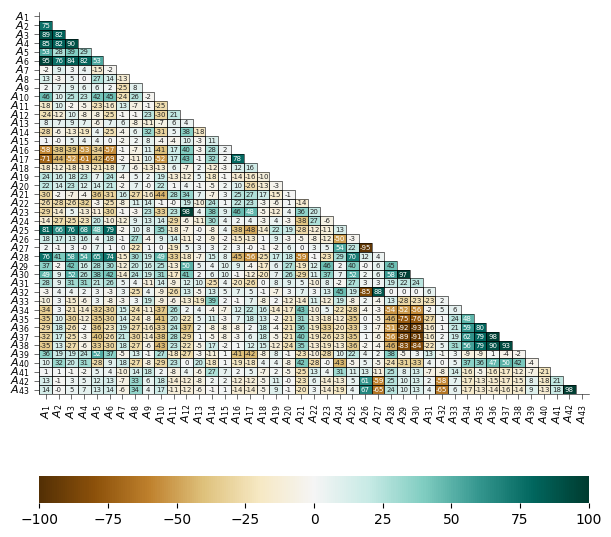

In [ ]:
line_width = 0.4
annot_size = 5
label_size = 8

corr_ = pp_plant_A.copy()
corr_.columns = label_corr_A
corr_df = corr_.corr(method='pearson')
corr_df_percent = corr_df * 100  # multiply by 100 for percentage scale

# Create mask to exclude upper triangle and diagonal
mask_ut = np.triu(np.ones(corr_df.shape), k=0)

# Plot heatmap for lower triangle only (excluding diagonal)
fig, ax = plt.subplots(figsize=(18/2.54, 18/2.54))

_ = sns.heatmap(corr_df_percent, mask=mask_ut.astype(bool), annot=True,
                cmap='BrBG', linewidth=0, linecolor='black',
                annot_kws={'size': annot_size, 'weight': 540, 'fontfamily': 'sans-serif'}, fmt='.0f', cbar=True, ax=ax, cbar_kws={'orientation': 'horizontal'}, 
                vmin=-100, vmax=100)


# Set axis labels
n = len(label_corr_A)
_ = ax.set_xticks(np.arange(n) + 0.5)  # positions centered on each heatmap cell
_ = ax.set_yticks(np.arange(n) + 0.5)
_ = ax.set_xticklabels(label_corr_A, size=label_size, rotation = 90)
_ = ax.set_yticklabels(label_corr_A, size=label_size, rotation = 0)

# Draw inner gridlines only for lower triangle (excluding diagonal)
n = corr_df_percent.shape[0]
for i in range(n):
    for j in range(i):  # j < i skips diagonal
        _ = ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=line_width))

_= ax.spines['left'].set_visible(True)
_= ax.spines['left'].set_linewidth(line_width)
_= ax.spines['left'].set_color('black')

_= ax.spines['bottom'].set_visible(True)
_= ax.spines['bottom'].set_linewidth(line_width)
_= ax.spines['bottom'].set_color('black')
_= ax.tick_params(axis='both', width= line_width,  length=3.5, direction='out')
plt.savefig("/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/Cbar_plant.pdf", bbox_inches='tight', transparent = True)  
_ = plt.show()


In [ ]:
corr_ = pp_plant_A.copy()

target_param = 'NOx content in the raw gas (preheater outlet)'  #  'CO2 content in the raw gas (preheater outlet)','CO content in the raw gas (preheater outlet)'
corr_values = corr_.corr(method='pearson')[target_param].drop(target_param)  # Drop self-correlation
corr_values = corr_values.abs().sort_values(ascending=False)
corr_df = corr_values.to_frame()
corr_df = corr_df*100
corr_df = corr_df.round(0).astype(int)
fig, ax = plt.subplots(figsize=(3, 10))  # Adjust figure size as needed
_= sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".0f", cbar=False, linewidths=0.5, linecolor='black', annot_kws={'size': 14})
_= plt.xticks(fontsize=15)  # Adjust the font size for x-axis labels
_= plt.yticks(fontsize=15)  
_= plt.show()

# Table for origin ploting

nox

In [ ]:
target_param = 'NOx' 
pp_plant_A = pp_plant_A[(pp_plant_A[target_param] >= 90) & (pp_plant_A[target_param] <= 1000)]
corr_ = pp_plant_A.copy()
 #  'CO2 content in the raw gas (preheater outlet)','CO content in the raw gas (preheater outlet)'
corr_values = corr_.corr(method='pearson')[target_param].drop(target_param)  # Drop self-correlation
corr_values = corr_values.abs().sort_values(ascending=False)
corr_df = corr_values.to_frame()
corr_df = corr_df*100
corr_df = corr_df.round(0).astype(int)

label_corr = [rf'A\-({i})' for i in range(1, len(label_corr_A) + 1)]
notation_df = pd.DataFrame({'short_names':list(pp_plant_A.columns) , 'notation':label_corr })

corr_df = corr_df.reset_index()
corr_df.columns = ['short_names', 'pearson_vals']
plot_corr_df = corr_df.merge(notation_df, on = 'short_names', how = 'left')
plot_corr_df = plot_corr_df[~plot_corr_df['short_names'].isin(['CO2','CO'])]

# plot_corr_df['Param'] = plot_corr_df['notation'].astype(str) + ' '+ plot_corr_df['short_names'].astype(str) 
# plot_corr_df.drop(columns=['short_names', 'notation'], inplace = True)
plot_corr_df.to_excel('/home/m3rg2000/Junaid_temporary/saved_data/general/plant_A_nox_PP_corr.xlsx', index = False)

co2

In [ ]:
pp_plant_A = total_filter[PP_reduced]
pp_plant_A.columns = short_names
target_param =  'CO2' #'CO content in the raw gas (preheater outlet)','NOx content in the raw gas (preheater outlet)'

pp_plant_A = pp_plant_A[(pp_plant_A[target_param] > 200) & (pp_plant_A[target_param] < 350)]
corr_ = pp_plant_A.copy()
corr_values = corr_.corr(method='pearson')[target_param].drop(target_param)  # Drop self-correlation
corr_values = corr_values.abs().sort_values(ascending=False)
corr_df = corr_values.to_frame()
corr_df = corr_df*100
corr_df = corr_df.round(0).astype(int)

label_corr = [rf'A\-({i})' for i in range(1, len(label_corr_A) + 1)]
notation_df = pd.DataFrame({'short_names':list(pp_plant_A.columns) , 'notation':label_corr })

corr_df = corr_df.reset_index()
corr_df.columns = ['short_names', 'pearson_vals']
plot_corr_df = corr_df.merge(notation_df, on = 'short_names', how = 'left')
plot_corr_df = plot_corr_df[~plot_corr_df['short_names'].isin(['CO','NOx'])]
# plot_corr_df['Param'] = plot_corr_df['notation'].astype(str) + ' '+ plot_corr_df['short_names'].astype(str) 
# plot_corr_df.drop(columns=['short_names', 'notation'], inplace = True)
plot_corr_df.to_excel('/home/m3rg2000/Junaid_temporary/saved_data/general/plant_A_co2_PP_corr.xlsx', index = False)

co

In [ ]:
pp_plant_A = total_filter[PP_reduced]
pp_plant_A.columns = short_names
target_param = 'CO'#'NOx content in the raw gas (preheater outlet)',  'CO2 content in the raw gas (preheater outlet)'
pp_plant_A = pp_plant_A[(pp_plant_A[target_param] > 90) & (pp_plant_A[target_param] < 800)]
corr_ = pp_plant_A.copy()
corr_values = corr_.corr(method='pearson')[target_param].drop(target_param)  # Drop self-correlation
corr_values = corr_values.abs().sort_values(ascending=False)
corr_df = corr_values.to_frame()
corr_df = corr_df*100
corr_df = corr_df.round(0).astype(int)

label_corr = [rf'A\-({i})' for i in range(1, len(label_corr_A) + 1)]
notation_df = pd.DataFrame({'short_names':list(pp_plant_A.columns) , 'notation':label_corr })

corr_df = corr_df.reset_index()
corr_df.columns = ['short_names', 'pearson_vals']
plot_corr_df = corr_df.merge(notation_df, on = 'short_names', how = 'left')
plot_corr_df = plot_corr_df[~plot_corr_df['short_names'].isin(['NOx',  'CO2'])]
# plot_corr_df['Param'] = plot_corr_df['notation'].astype(str) + ' '+ plot_corr_df['short_names'].astype(str) 
# plot_corr_df.drop(columns=['short_names', 'notation'], inplace = True)
plot_corr_df.to_excel('/home/m3rg2000/Junaid_temporary/saved_data/general/plant_A_co_PP_corr.xlsx', index = False)

# Data distribution

In [6]:
a = pp_description[['excel_naming', 'unit']]
a = a[a['excel_naming'].isin(PP_reduced)]
a['short_names'] = short_names
a.reset_index(inplace=True)
a.drop(columns=['index'], inplace = True)
label_corr_A = [rf'$A_{{{i}}}$' for i in range(1, pp_plant_A.shape[1] + 1)]
units = [
    r"$^\circ$C",
    r"$^\circ$C",
    r"$^\circ$C",
    r"$^\circ$C",
    r"$^\circ$C",
    r"$^\circ$C",
    r"%",
    "$10^3$PPM",
    r"PPM",
    r"PPM",
    r"$^\circ$C",
    r"t/h",
    r"m$^3$/h",
    r"m$^3$/h",
    r"$^\circ$C",
    r"t/h",
    r"%",
    r"%",
    r"$^\circ$C",
    r"MT/h",
    "$10^3$Am$^3$/h",
    r"$^\circ$C",
    r"t/h",
    r"CFM",
    r"$^\circ$C",
    r"m$^3$/h",
    r"$^\circ$C",
    r"$^\circ$C",
    r"A",
    r"%",
    r"kW",
    r"kW",
    r"mbar",
    r"mbar",
    r"mbar",
    r"mbar",
    r"mbar",
    r"mbar",
    r"mbar",
    r"mbar",
    r"bar",
    r"mbar",
    r"mbar"]
a['unit'] = units


In [7]:
pp_naming_list = a['short_names'].to_list()
full = db0[PP_reduced]
full.columns = short_names

# Gives plots separately

In [ ]:
#### Some nice palletes:

background= '#aec3b0'
foreground = '#124559'  

background= '#3c6e71'
foreground = '#353535' 

background= '#ccc5b9'
foreground = '#403d39'  

background= '#89b0ae' # this
foreground = '#4d4847'  

background= '#d1be9c'
foreground = '#7d4f50'  

background= '#8baaad'
foreground = '#4d4847'  

background= '#8baaad'
foreground = '#1c3738'  

background= '#ccc5b9' #this
foreground = '#1e1e24' 

background= '#8baaad' # this
foreground = '#000f08'  

0


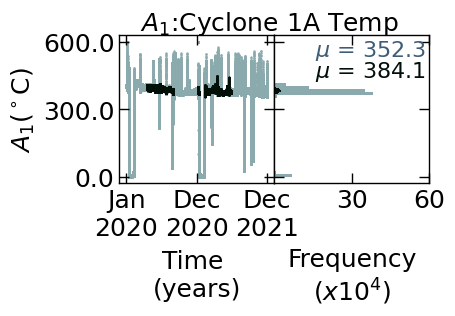

1


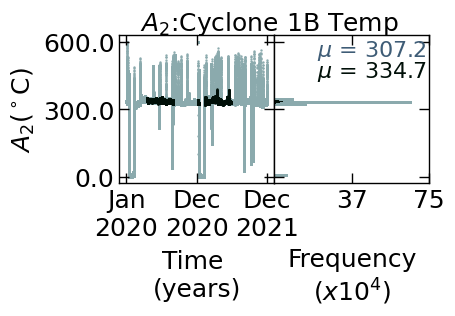

2


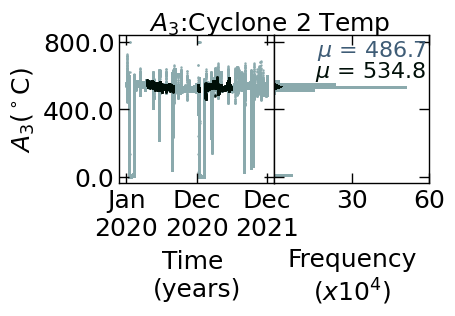

3


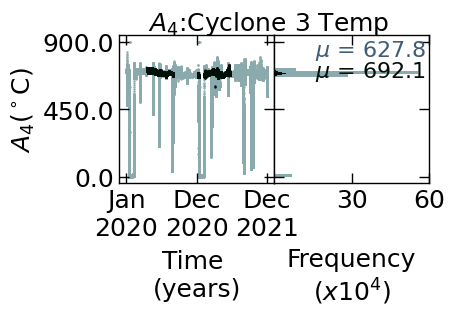

4


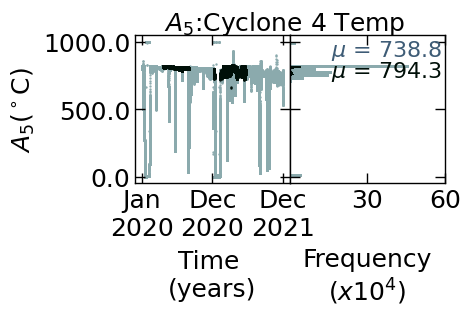

5


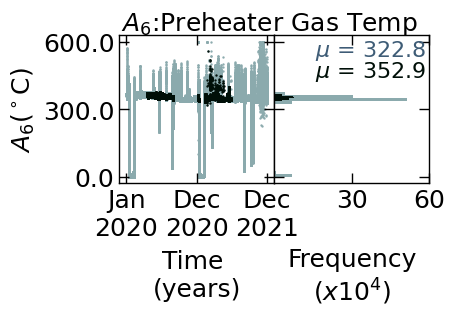

6


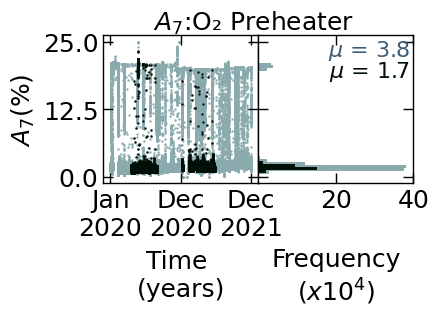

7


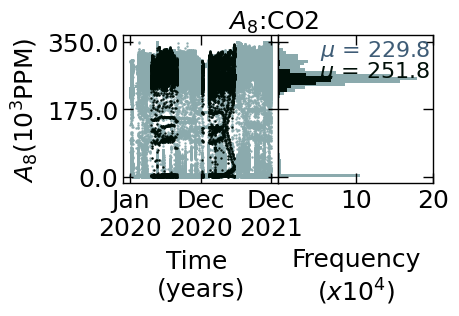

8


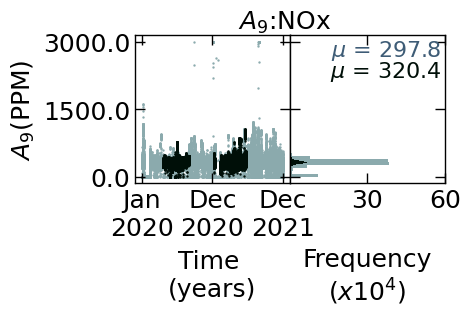

9


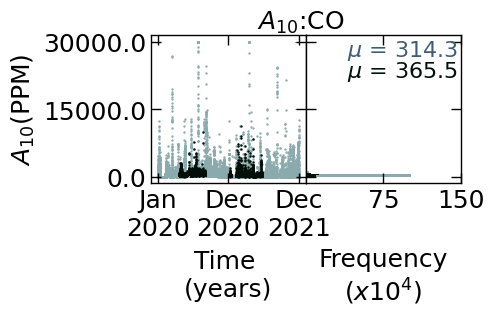

10


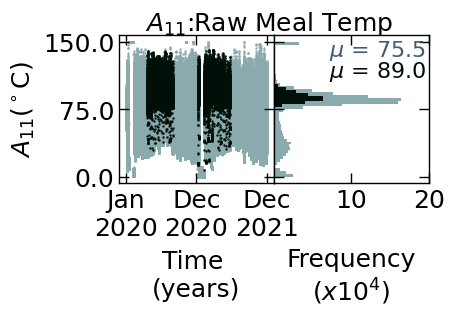

11


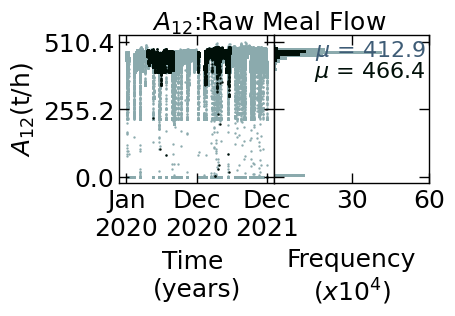

12


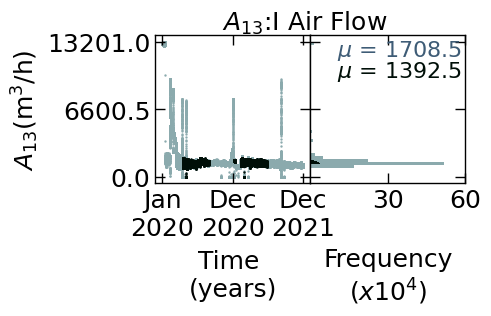

13


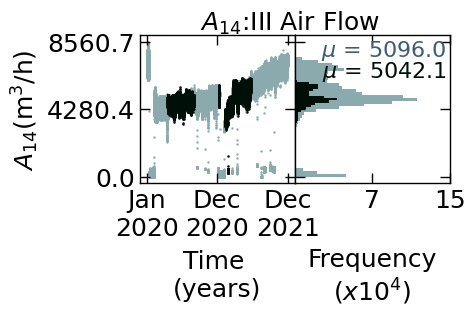

14


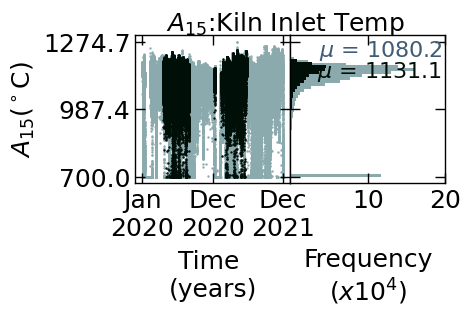

15


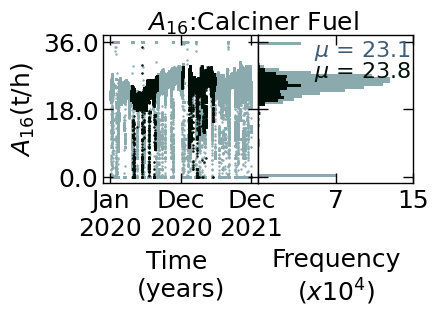

16


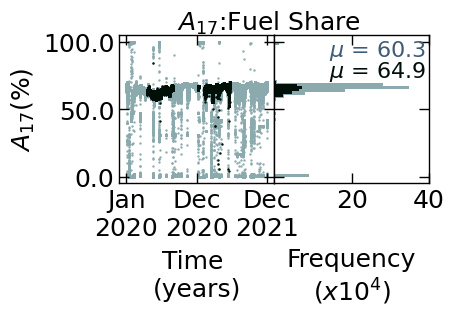

17


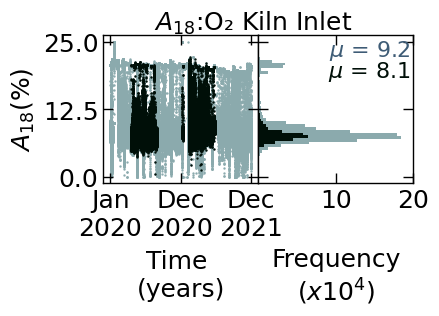

18


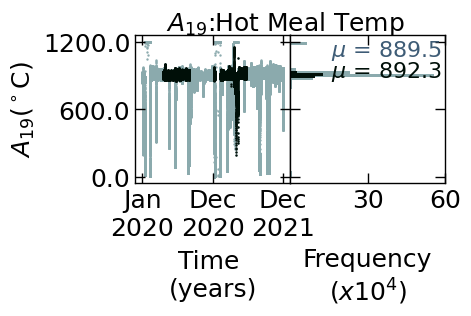

19


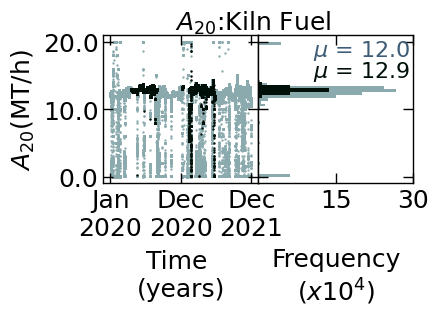

20


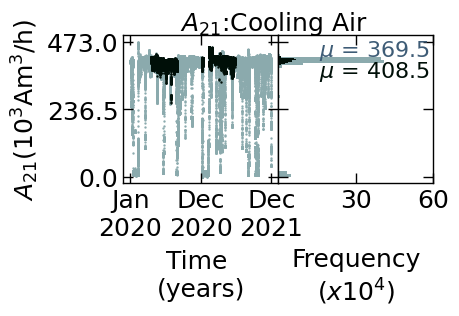

21


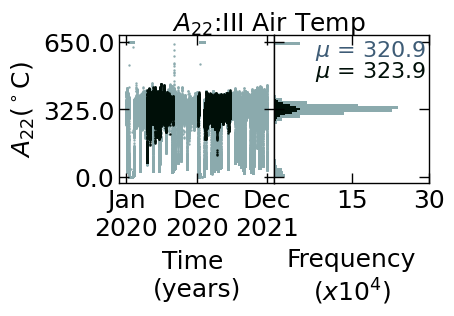

22


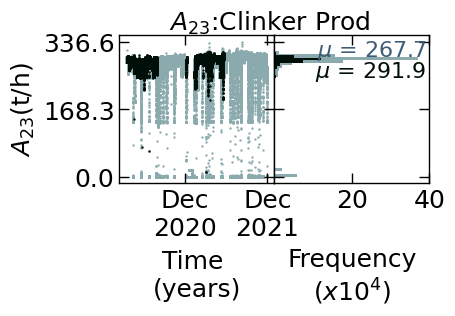

23


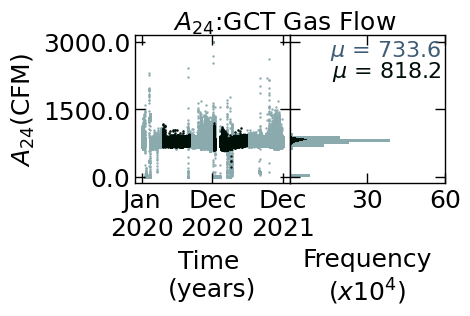

24


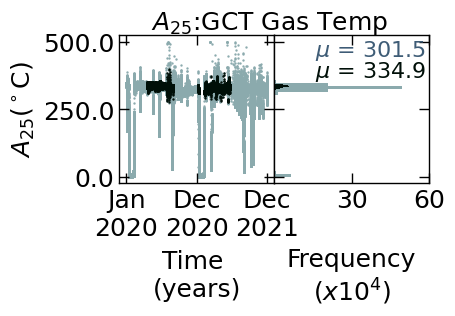

25


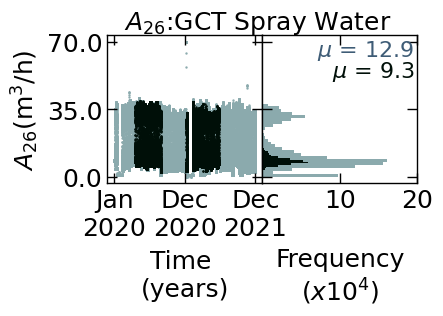

26


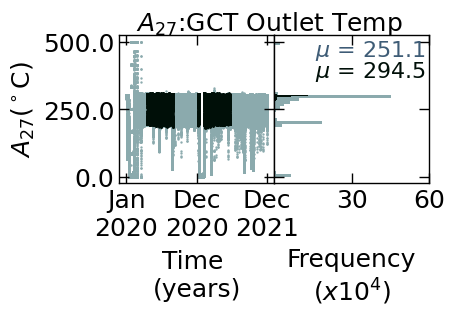

27


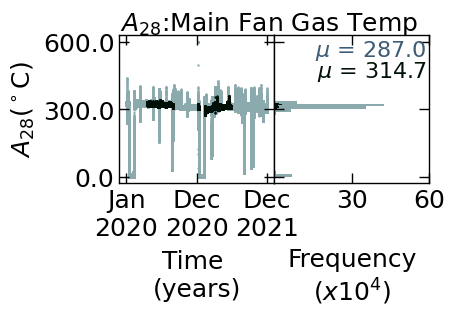

28


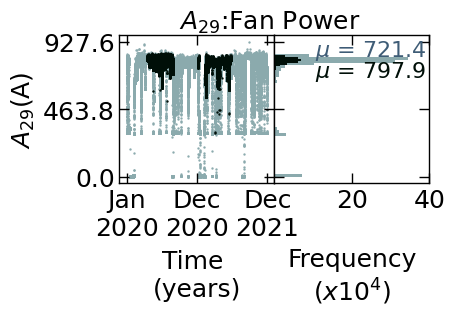

29


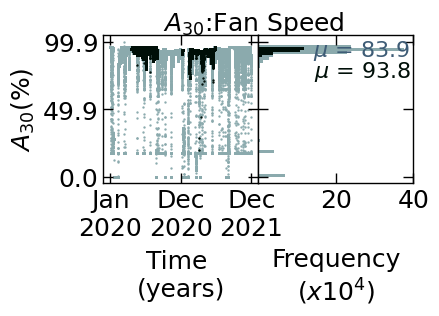

30


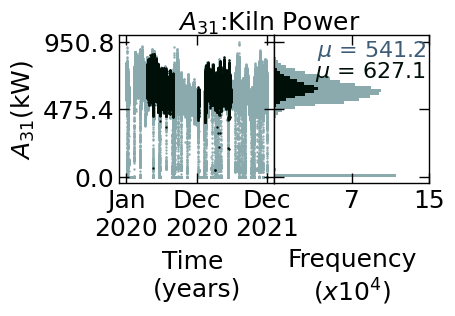

31


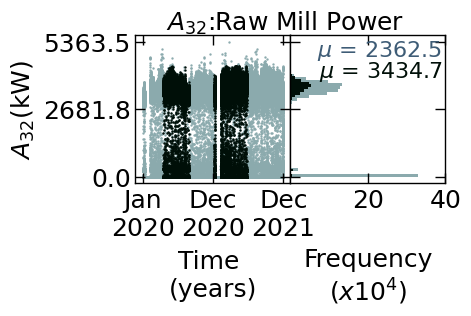

32


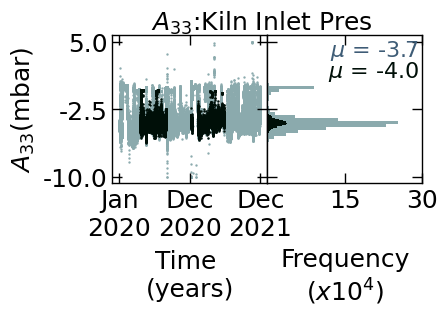

33


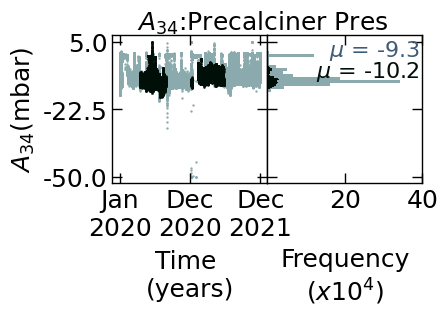

34


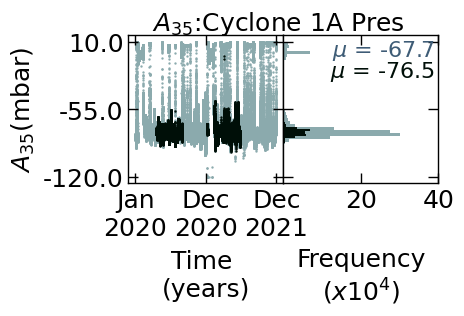

35


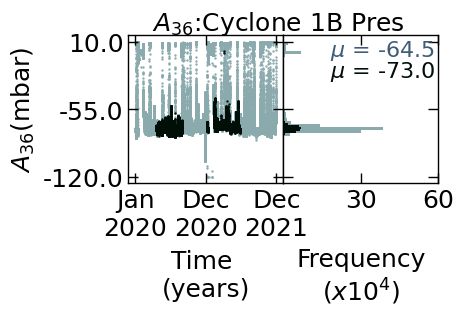

36


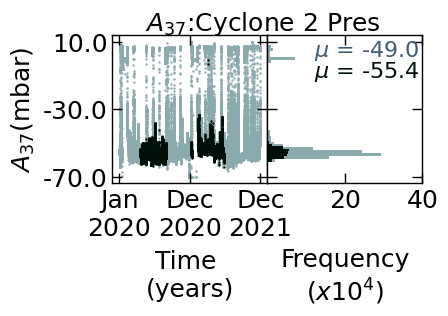

37


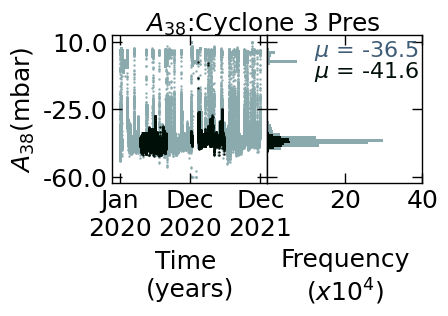

38


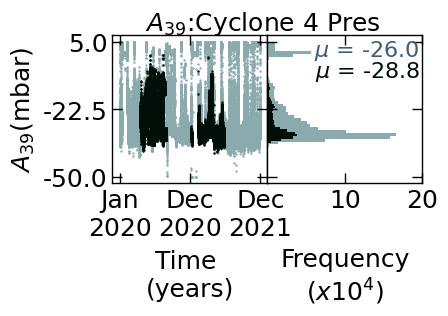

39


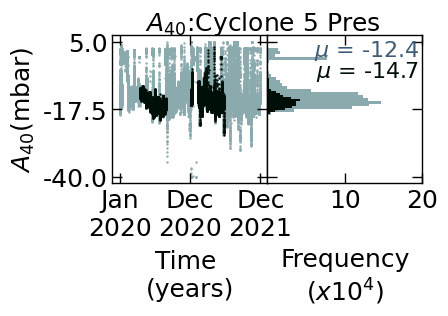

40


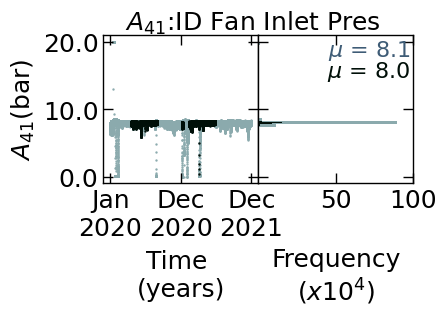

41


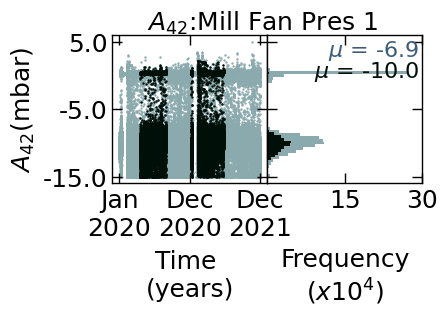

42


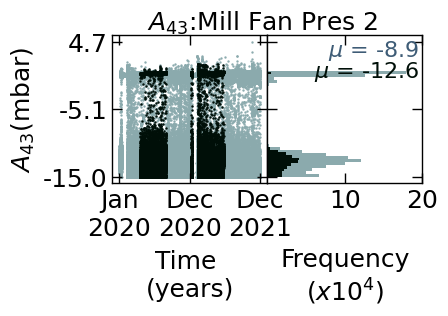

In [ ]:
background= '#8baaad'
foreground = '#000f08'  


matplotlib.rcParams['axes.linewidth'] = 1
variable = full.copy(deep= True) # Give raw data here
filter_var = pp_plant_A.copy(deep= True)  #Give filtered data here.=
filter_var.reset_index(inplace = True)
x_vals = list(filter_var['index'].values)
filter_var.drop(columns=['index'], inplace = True)
s = 18
n = 0
for column in variable:
    print(n)
    fig, ax = plt.subplots(1,2,figsize=(4,2),squeeze = False, sharey='col' )
    _=fig.suptitle(label_corr_A[n]+':'+ pp_naming_list[n], fontsize=s, fontweight='normal')
    _=plt.subplots_adjust(wspace=0, top = 0.85) # top = 0.85 (default) [distance of title from top]
    raw = variable[column].values
    # raw = [x for x in raw if not np.isnan(x)]  # removing Nan. Becs they are not plotted
    filtered_raw = filter_var[column].values
    mean_raw = np.nanmean(raw)
    mean_filtered = np.nanmean(filtered_raw)

    [a, b] = list(variable.describe()[column][['min', 'max']])
    mini,mid, maxi = average(a, b)
    _= ax[0,0].set_yticks([mini,mid, maxi],[mini,mid, maxi],fontsize = s, fontweight = 'normal') 
    _=ax[0,0].set_xlabel('Time \n(years)', fontweight = 'normal', fontsize = s,labelpad = 7)
    _=ax[0,0].set_xticks([0,len(raw)/2 ,len(raw)], labels = ['Jan\n2020','Dec\n2020' ,'Dec\n2021'], fontsize = s, fontweight= 'normal')
    # _=ax[0,0].plot(np.arange(0,len(raw)), raw, linewidth=1, color= foreground)
    # _=ax[0,0].plot(x_vals, filtered_raw, linewidth=1, color= background)
    _=ax[0,0].scatter(np.arange(0,len(raw)), raw, s=0.5, color= background, rasterized=True)
    _=ax[0,0].scatter(x_vals, filtered_raw, s=0.5, color= foreground, rasterized=True)

    _= ax[0,0].tick_params(which = 'major', width= 1, length =7)
    _= ax[0,0].tick_params(which = 'minor', width= 1, length =4)
    _= ax[0,0].tick_params(axis='x', direction ='in', which = 'both')
    _= ax[0,0].tick_params(axis='y', direction ='in', which = 'both')
    _= ax[0,0].tick_params(axis='y', which='major', right= True)
    _= ax[0,0].tick_params(axis='y', which='minor', right= True)
    _= ax[0,0].tick_params(axis='y', which='major', left= True)
    _= ax[0,0].tick_params(axis='y', which='minor', left= True)
    _= ax[0,0].tick_params(axis='x', which='major', top = True)
    _= ax[0,0].tick_params(axis='x', which='minor', top = True)
    _= ax[0,0].set_ylabel(f'{label_corr_A[n]}' +'('+f'{units[n]}'+ ')', fontsize=s, fontweight='normal') #,labelpad = s

    _= ax[0,1].set_xlabel('Frequency\n($x10^4$)', fontsize=s, fontweight='normal', labelpad=25)
    _= ax[0,1].set_yticks([mini,mid, maxi],[mini,mid, maxi],fontsize = 0, fontweight = 'normal') 
    _= ax[0,1].tick_params(which = 'major', width= 1, length =7)
    _= ax[0,1].tick_params(which = 'minor', width= 1, length =4)
    _= ax[0,1].tick_params(axis='x', direction ='in', which = 'both')
    _= ax[0,1].tick_params(axis='y', direction ='in', which = 'both')
    _= ax[0,1].tick_params(axis='y', which='major', right= True)
    _= ax[0,1].tick_params(axis='y', which='minor', right= True)
    _= ax[0,1].tick_params(axis='y', which='major', left= True)
    _= ax[0,1].tick_params(axis='y', which='minor', left= True)
    _= ax[0,1].tick_params(axis='x', which='major', top = True)
    _= ax[0,1].tick_params(axis='x', which='minor', top = True)
    _ = plt.hist(raw, bins = int(1+3.3*np.log(len(raw))), ec= 'none', color = background, density = False , label = 'cleaned data', alpha = 1, orientation= 'horizontal', rasterized=True)
    _ = plt.hist(filtered_raw, bins = int(1+3.3*np.log(len(filtered_raw))), ec= 'none', color = foreground, density = False , label = 'cleaned data', alpha = 1, orientation= 'horizontal', rasterized=True)
    
    _= ax[0,1].text(
    0.98, 0.98,
    rf'$\mu$ = {mean_raw:.1f}',
    transform=ax[0,1].transAxes,
    fontsize=s-2,
    fontweight='normal',
    color='#3e5c76',    #background,
    ha='right', va='top')
    
    _= ax[0,1].text(
    0.98, 0.84,
    rf'$\mu$ = {mean_filtered:.1f}',
    transform=ax[0,1].transAxes,
    fontsize=s-2,
    fontweight='normal',
    color=foreground,
    ha='right', va='top')

    maxi = int(np.max(ax[0,1].get_xticks()))
    midi = int(np.max(ax[0,1].get_xticks())/2)
    _= ax[0,1].set_xticks([midi, maxi],[int(midi/10000), int(maxi/10000)],fontsize = s, fontweight = 'normal') 
    n+=1
    plt.savefig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/Data_visulalizaiton/plant_A/PP_{n}.pdf', bbox_inches='tight', transparent = True, dpi = 1000)
    plt.show()

# Plant Comparison parity plot

# Plant A nox

In [8]:
np.random.seed(1002)
random.seed(0)

ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
##################################################################### remove nestor's unreliable params
X.drop(['Exit temperature from each preheater cyclone (Stage 5)',
'Flue gas outlet temperature (calciner outlet)',
'Flue gas O2 content (calciner outlet)',
'Clinker outlet temperature'], axis = 1, inplace = True)
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
print(f'Datapoints test-train split = {len(X)}')
y = y2
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

plant_1_nox_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_1_nox.pkl','rb')) 
nox_plant1_ac = y_test[list(y_test.columns)[0]].to_list()
nox_plant1_pr = list(plant_1_nox_model.predict(X_test))

Datapoints test-train split = 277079


# Plant A CO

In [9]:
np.random.seed(1002)
random.seed(0)

# < 1300 PPM
# ALL = total_filter.copy(deep = True)
# ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 1370)]
# X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
# y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]

# < 800 PPM
ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 800)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

plant_1_co_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co/plant_1_co.pkl','rb')) 
co_plant1_ac = y_test[list(y_test.columns)[0]].to_list()
co_plant1_pr = list(plant_1_co_model.predict(X_test))

# Plant A CO2

In [10]:
np.random.seed(1002)
random.seed(0)

ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO2 content in the raw gas (preheater outlet)'] > 200) & (ALL['CO2 content in the raw gas (preheater outlet)'] < 350)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO2 content in the raw gas (preheater outlet)']]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

plant_1_co2_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co2/plant_1_co2.pkl','rb')) 
co2_plant1_ac = y_test[list(y_test.columns)[0]].to_list()
co2_plant1_pr = list(plant_1_co2_model.predict(X_test))

# plant B

In [11]:
np.random.seed(1002)
random.seed(0)

model_data = filtered_palnt_b.copy()
X = model_data.iloc[:,1:]
y = model_data.iloc[:,[0]]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=100)

plant_2_nox_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_2_nox.pkl','rb')) 
nox_plant2_ac = y_test[list(y_test.columns)[0]].to_list()
nox_plant2_pr = list(plant_2_nox_model.predict(X_test))

# Plant C

In [12]:
np.random.seed(1002)
random.seed(0)

model_data = filtered_palnt_c.copy()
X = model_data.iloc[:,1:]
y = model_data.iloc[:,[0]]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=100)

plant_3_nox_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_3_nox.pkl','rb')) 
nox_plant3_ac = y_test[list(y_test.columns)[0]].to_list()
nox_plant3_pr = list(plant_3_nox_model.predict(X_test))

# Plant D

In [67]:
np.random.seed(1002)
random.seed(0)

X = filtered_palnt_d.iloc[:,1:]
y = filtered_palnt_d.iloc[:,[0]]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=100)

# Separate scalers for X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scale inputs (X)
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# Scale outputs (y)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten() # Convert y_df to NP arrays before reshaping
y_test_s = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# plant_4_co_model = pickle.load(open('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_4_co.pkl','rb')) 
plant_4_co_model = pickle.load(open(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant4/xgb_best.pkl','rb')) 
co_plant4_ac = y_test[list(y_test.columns)[0]].to_list()
# test_pred_s = plant_4_co_model.predict(X_test_s).reshape(-1,1)
# co_plant4_pr = scaler_y.inverse_transform(test_pred_s)
co_plant4_pr = list(plant_4_co_model.predict(X_test))
# train_pred_s = plant_4_co_model.predict(X_train_s).reshape(-1,1)
# train_pred = scaler_y.inverse_transform(train_pred_s)

In [31]:

# col1 = '#4B0082'             # Dark Indigo (purple)
# col2 = '#800000'              # Maroon (dark red)
# col3 = '#003366' # Dark Blue

# col4 = '#006400'               # Dark Gre

col4 = 'grey'            # light orignal
col3 = '#C19875'            
col1 = '#96BBBB'  
col2 = '#618985'    

# col4= '#4D4D4D'             # dark duplicate  
# col3= '#8B5E3C'           
# col1= '#2E8B8B'  
# col2= '#2E5E5A'             

In [36]:
matplotlib.rcParams['axes.linewidth'] = 0.5
matplotlib.rcParams['text.color'] = '#343a40'
matplotlib.rcParams['axes.labelcolor'] = '#343a40'
matplotlib.rcParams['xtick.color'] = '#343a40'
matplotlib.rcParams['ytick.color'] = '#343a40'
matplotlib.rcParams['axes.edgecolor'] = '#343a40' 
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'

# Parity

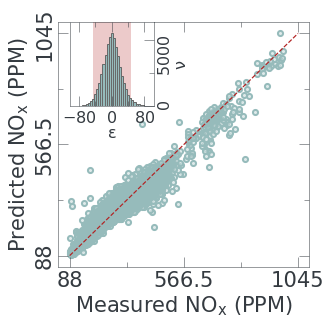

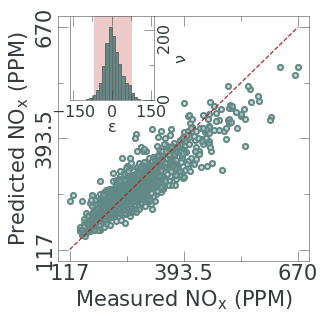

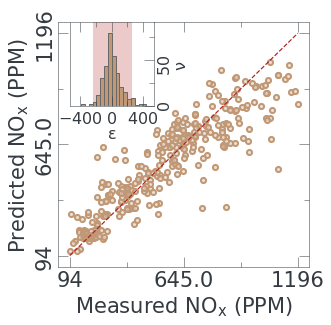

In [74]:
plot_fun_nox(nox_plant1_ac, nox_plant1_pr, col1, label = 'nox_plant1')
plot_fun_nox(nox_plant2_ac, nox_plant2_pr, col2, label = 'nox_plant2')
plot_fun_nox(nox_plant3_ac, nox_plant3_pr, col3, label = 'nox_plant3')


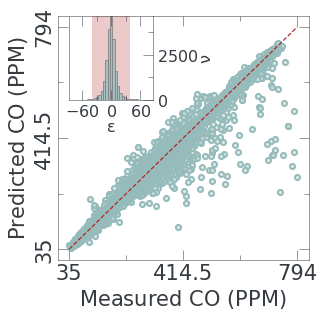

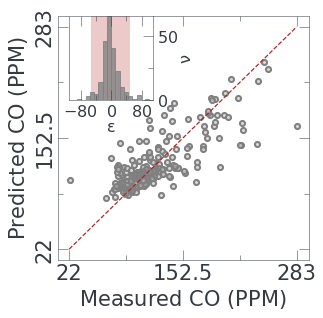

In [75]:
plot_fun_co(co_plant1_ac, co_plant1_pr, col1, label = 'co_plant1')
plot_fun_co(co_plant4_ac, co_plant4_pr, col4, label = 'co_plant4')

# Range comparison

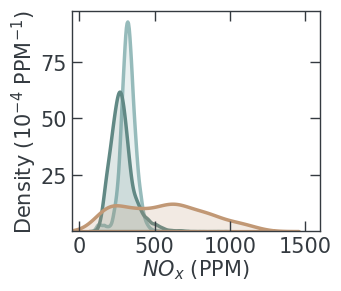

In [ ]:
s = 15
fig, ax = plt.subplots(figsize=(3.5,3))
_= ax.set_xlim(-50,1600)
_ = ax.set_xlabel('$NO_{x}$ (PPM)', fontsize=s, fontweight='normal', labelpad=1)
_ = ax.set_ylabel('Density ($10^{-4}$ PPM$^{-1}$)', fontsize=s, fontweight='normal', labelpad=1)
_= plt.yticks([0.0025,0.0050,0.0075], [25,50,75], rotation = 0, fontsize = s)
_= plt.xticks([0, 500,1000, 1500], [0,500,1000, 1500], rotation = 0, fontsize = s)
_ = ax.tick_params(which='major', width=1, length=7)
_ = ax.tick_params(which='minor', width=1, length=4)
_ = ax.tick_params(axis='x', direction='in', which='both', top=True)
_ = ax.tick_params(axis='y', direction='in', which='both', left=True, right=True)
_= sns.kdeplot(nox_plant1_ac, ax=ax, bw_adjust=1, color=col1, label='Plant 1', fill=True, alpha=0.2, linewidth=2.5)
_= sns.kdeplot(nox_plant2_ac, ax=ax, bw_adjust=1, color=col2, label='Plant 2', fill=True, alpha=0.2, linewidth=2.5)
_= sns.kdeplot(nox_plant3_ac, ax=ax, bw_adjust=1, color=col3, label='Plant 3', fill=True, alpha=0.2, linewidth=2.5)
plt.tight_layout()
plt.savefig("/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/KDE_nox.pdf", bbox_inches='tight', transparent = True)  
plt.show()


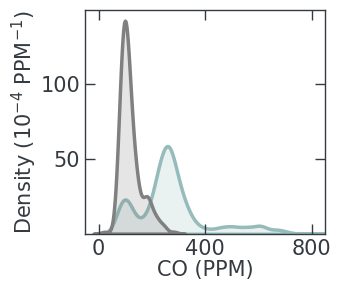

In [ ]:
s = 15
fig, ax = plt.subplots(figsize=(3.5,3))
_= ax.set_xlim(-50,850)
_ = ax.set_xlabel('CO (PPM)', fontsize=s, fontweight='normal', labelpad=1)
_ = ax.set_ylabel('Density ($10^{-4}$ PPM$^{-1}$)', fontsize=s, fontweight='normal', labelpad=1)
_= plt.yticks([0.005, 0.010], [50, 100], rotation = 0, fontsize = s)
_= plt.xticks([0, 400, 800], [0,400, 800], rotation = 0, fontsize = s)
_ = ax.tick_params(which='major', width=1, length=7)
_ = ax.tick_params(which='minor', width=1, length=4)
_ = ax.tick_params(axis='x', direction='in', which='both', top=True)
_ = ax.tick_params(axis='y', direction='in', which='both', left=True, right=True)
_= sns.kdeplot(co_plant1_ac, ax=ax, bw_adjust=1, color=col1, label='Plant 1', fill=True, alpha=0.2, linewidth=2.5)
_= sns.kdeplot(co_plant4_ac, ax=ax, bw_adjust=1, color=col4, label='Plant 2', fill=True, alpha=0.2, linewidth=2.5)
plt.savefig("/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/KDE_co.pdf", bbox_inches='tight', transparent = True)  
plt.tight_layout()
plt.show()


# Mean & Std (Error metrics) for 10 seeds of plant comparison

In [3]:
seeds_plant1_co = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co.pkl')
seeds_plant1_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_nox.pkl')
seeds_plant2_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant2_nox.pkl')
seeds_plant3_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant3_nox.pkl')
seeds_plant4_co = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant4_co.pkl')
seeds_plant1_co2 = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co2.pkl')

In [7]:
df = seeds_plant1_nox.copy()
mean_row = np.round(df.mean(),2)
std_row = np.round(df.std(),3)
mean_row.name = 'mean'
std_row.name = 'std'
pd.concat([df, pd.DataFrame([mean_row, std_row])], axis=0)

,r2 train,r2 test,mae train,mae test,mape train,mape test
0,0.965,0.836,8.275,17.871,2.646,5.703
1,0.965,0.837,8.282,17.865,2.649,5.699
2,0.965,0.837,8.262,17.888,2.641,5.706
3,0.964,0.837,8.306,17.865,2.655,5.699
4,0.964,0.836,8.295,17.871,2.651,5.702
5,0.964,0.837,8.295,17.859,2.652,5.697
6,0.965,0.836,8.289,17.886,2.650,5.707
7,0.965,0.837,8.272,17.865,2.646,5.702
8,0.964,0.836,8.375,17.909,2.677,5.714
9,0.965,0.836,8.266,17.868,2.642,5.700


# Plant compare (NOx): Model Benchmark

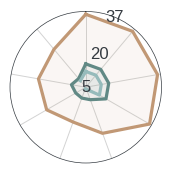

In [ ]:
linewidth = 2.3
lw_grid= 0.7
grid_col = 'lightgray'
alpha = 0.08
text_font = 12
#          LR     laso  ridge.  elas.   rf.  xgb.   svr.    gpr.     nn
plant1 = [11.64, 11.64, 11.64, 11.64,  5.99, 5.69,  np.NaN, np.NaN,  8.56] 
plant2 = [14.85, 14.83, 14.83, 14.85, 10.61, 9.89,  9.90,   11.15,   9.72]
plant3 = [35.79, 35.79, 35.78, 36.10, 25.71, 19.95, 24.08,   25.30,  25.90]
maxi = max(plant1+plant2+plant3)
mini = min(plant1+plant2+plant3)
y_min = math.floor(mini)
y_max = math.ceil(maxi)
avg = int((maxi+mini)/2)
axial_label = [y_min , avg, y_max] 
labels = ['' for i in range(len(values))]
num_vars = len(labels)
theta = radar_factory(num_vars, frame='circle')
inch= 2.54

fig, ax = plt.subplots(figsize=(5/inch,5/inch), subplot_kw=dict(projection='radar'))
spine_param(ax, lw= 0.5, col= '#343a40')

_= ax.plot(theta, plant3, color=col3, linewidth=linewidth, zorder = 18)  
_= ax.fill(theta, plant3, color=col3, alpha=alpha, zorder = 18) 

_= ax.plot(theta, plant2, color=col2, linewidth=linewidth, zorder = 19)  
_= ax.fill(theta, plant2, color=col2, alpha=alpha, zorder = 19)  

_= ax.plot(theta, plant1, color=col1, linewidth=linewidth, zorder = 20)  
_= ax.fill(theta, plant1, color=col1, alpha=alpha, zorder = 20)  

_= ax.set_varlabels(labels)
for label in ax.get_xticklabels():
    _= label.set_fontweight('normal')  
    _= label.set_fontsize(text_font) 
_= ax.tick_params(pad=20) 

_= ax.xaxis.grid(True, color=grid_col, linestyle='-', linewidth= lw_grid) # radial grid
# _= ax.xaxis.grid(False)

# _= ax.yaxis.grid(True, linestyle=(5, (10,3)), color= grid_col, linewidth=lw_grid, alpha=0.7) # circular grid
_= ax.yaxis.grid(False)

_= ax.set_ylim(y_min, y_max)
radial_labels = axial_label  
positions = axial_label
_= ax.set_yticklabels([])
for label, pos in zip(radial_labels, positions):
    _= ax.text(np.pi / 8, pos, label, horizontalalignment='center', verticalalignment='center',fontsize=text_font, fontweight = 'normal', color = '#343a40', zorder = 100)
save_fig('/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/nox_all_model_bench.pdf')
plt.show()

# Plant compare (CO): Model Benchmark

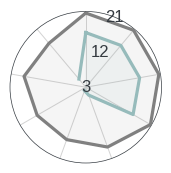

In [ ]:
linewidth = 2.3
lw_grid= 0.7
grid_col = 'lightgray'
alpha = 0.08
text_font = 12
#          LR     Lasso    Ridge.  elas.      rf.       xgb.    svr.        gpr.     nn
plant1 = [15.98,  15.96,  15.98,   15.97,   5.00,     3.70 ,   np.NaN,   np.NaN,   5.53] 
plant4 = [20.62,   20.66,   20.62,   20.74,  18.12,   16.25,   16.34,    17.89,   16.61]

maxi = max(plant1+plant4)
mini = min(plant1+plant4)
y_min = math.floor(mini)
y_max = math.ceil(maxi)
avg = int((maxi+mini)/2)
axial_label = [y_min , avg, y_max] 
labels = ['' for i in range(len(values))]
num_vars = len(labels)
theta = radar_factory(num_vars, frame='circle')
inch= 2.54

fig, ax = plt.subplots(figsize=(5/inch,5/inch), subplot_kw=dict(projection='radar'))
spine_param(ax, lw= 0.5, col= '#343a40')

_= ax.plot(theta, plant4, color=col4, linewidth=linewidth, zorder = 19)  
_= ax.fill(theta, plant4, color=col4, alpha=alpha, zorder = 19) 

_= ax.plot(theta, plant1, color=col1, linewidth=linewidth, zorder = 20)  
_= ax.fill(theta, plant1, color=col1, alpha=alpha, zorder = 20)  

_= ax.set_varlabels(labels)
for label in ax.get_xticklabels():
    _= label.set_fontweight('normal')  
    _= label.set_fontsize(text_font) 
_= ax.tick_params(pad=20) 

_= ax.xaxis.grid(True, color=grid_col, linestyle='-', linewidth= lw_grid) # radial grid
# _= ax.xaxis.grid(False)

# _= ax.yaxis.grid(True, linestyle=(5, (10,3)), color= grid_col, linewidth=lw_grid, alpha=0.7,zorder = 1) # circular grid
_= ax.yaxis.grid(False)

_= ax.set_ylim(y_min, y_max)
radial_labels = axial_label  
positions = axial_label
_= ax.set_yticklabels([])
for label, pos in zip(radial_labels, positions):
    _= ax.text(np.pi / 8, pos, label, horizontalalignment='center', verticalalignment='center',fontsize=text_font, fontweight = 'normal', color = '#343a40', zorder = 100)  #test params
save_fig('/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/co_all_model_bench.pdf')
plt.show()

# Radar train/val/test for NOx palnt1, 2 and 3

In [8]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [ ]:
# def min_max_for_plots(case):
#     if case =='r2_one':
#         [min,max, buffer] = [0.45, 0.94, 0]
#     elif case == 'mae_one':
#         [min,max, buffer] = [0, 1.2, 0]
#     elif case == 'mape_one':
#         [min,max, buffer] = [0, 2, 0]
#     elif case =='r2_two':
#         [min,max, buffer] = [ 0.45, 0.93, 0]
#     elif case == 'mae_two':
#         [min,max, buffer] = [ 0, 1.23, 0]
#     elif case == 'mape_two':
#         [min,max, buffer] = [ 0,8, 0]  
#     elif case =='r2_three':
#         [min,max, buffer] = [ 0, 0.8, 0]
#     elif case == 'mae_three':
#         [min,max, buffer] = [0, 0.4,0 ]
#     elif case == 'mape_three':
#         [min,max, buffer] = [ 0,2,0]  
#     return(min, max, buffer)

In [37]:
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_train_nox.pkl", "rb") as f:   
    train_plant_1_nox = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_val_nox.pkl", "rb") as f:   
    val_plant_1_nox = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_test_nox.pkl", "rb") as f:   
    test_plant_1_nox = pickle.load(f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_train_co.pkl", "rb") as f:   
    train_plant_1_co = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_val_co.pkl", "rb") as f:   
    val_plant_1_co = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_test_co.pkl", "rb") as f:   
    test_plant_1_co = pickle.load(f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_train.pkl", "rb") as f:   
    train_plant_2 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_val.pkl", "rb") as f:   
    val_plant_2 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_test.pkl", "rb") as f:   
    test_plant_2 = pickle.load(f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_train.pkl", "rb") as f:   
    train_plant_3 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_val.pkl", "rb") as f:   
    val_plant_3 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_test.pkl", "rb") as f:   
    test_plant_3 = pickle.load(f)

with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_train.pkl", "rb") as f:   
    train_plant_4 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_val.pkl", "rb") as f:   
    val_plant_4 = pickle.load(f)
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant4_test.pkl", "rb") as f:   
    test_plant_4 = pickle.load(f)

In [4]:
def train_val_test_radar(train_values,validation_values,test_values, case, train_col, val_col, test_col, emission): 
    # mini, maxi, buffer = min_max_for_plots(case)
    s_label = 0
    s_limit = 15
    lw = 2.5
    alpha = 0.09  # 0.04
    values = np.array([train_values, validation_values, test_values])
    maxi = np.max(values)
    mini = np.min(values)
    avg = np.round((maxi+mini)/2,2)
    axial_label = [mini , avg, maxi] 
    labels = [f"{model}\n({train}, {val}, {test})" for model, train, val, test in zip(titles, train_values, validation_values, test_values)]
    # Create the radar chart
    num_vars = len(labels)
    theta = radar_factory(num_vars, frame='polygon')  #circle, polygon

    fig, ax = plt.subplots(figsize=(3.7,3.7), subplot_kw=dict(projection='radar'))
    spine_param(ax, lw= 0.5, col= '#343a40')
    ax.plot(theta, test_values, color= test_col, linewidth=lw)  # Plot the values
    ax.fill(theta, test_values, color= test_col , alpha= alpha)   # Fill the area under the plot

    ax.plot(theta, validation_values, color= val_col , linewidth=lw)  # Plot the values
    ax.fill(theta, validation_values, color= val_col, alpha=alpha)   # Fill the area under the plot

    ax.plot(theta, train_values, color= train_col, linewidth=lw)  # Plot the values
    ax.fill(theta, train_values, color= train_col , alpha=alpha)   # Fill the area under the plot

    ax.set_varlabels(labels)
    for label in ax.get_xticklabels():
        label.set_fontweight('normal')  # Change to 'normal' for regular weight
        label.set_fontsize(s_label) 
        label.set_color('white')   # set the color of lable here
    ax.tick_params(pad=15) 
    _= ax.yaxis.set_major_locator(MaxNLocator(nbins=3)) # how many circular grid lines u want
    ax.yaxis.grid(True, linestyle=(5, (10,3)))
    lim = np.max(values)

    # _= ax.set_ylim(mini, maxi)
    radial_labels = axial_label  
    positions = axial_label          # Radial positions for each label (0 to 1 scale)

    ax.set_yticklabels([])
    for label, pos in zip(radial_labels, positions):
        ax.text(0.27, pos, label,  # 0.27 is the degrees of angle from the vertical in anitclockwise 
                horizontalalignment='center', verticalalignment='center',
                fontsize=s_limit, color='#343a40', fontweight = 'normal')  # Adjust fontsize and color as needed
    if emission == 'nox':
        save_fig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/radar_nox/{case}.pdf')
    elif emission == 'co':
        save_fig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/radar_co/{case}.pdf')
    else: 
        save_fig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/radar_co2/{case}.pdf')
    print(case)
    plt.show()

# NOx benchmark

In [30]:
columns=['model', 'train', 'val', 'test']
plant1 = {'model' : ['Linear regression',       'Lasso',      'Ridge',        'Elastic net',      'Random forest',      'XGBoost',            'SVR',                'GPR',                'NN' ],
        'train' :train_plant_1_nox ,
        'val' :  val_plant_1_nox ,
        'test' :test_plant_1_nox  
}

plant2 = {'model' : ['Linear regression',       'Lasso',      'Ridge',        'Elastic net',      'Random forest',      'XGBoost',            'SVR',                'GPR',                'NN' ],
        'train' :train_plant_2 ,
        'val' : val_plant_2 ,
        'test' :test_plant_2
}

plant3 = {'model' : ['Linear regression',             'Lasso',            'Ridge',        'Elastic net',          'Random forest',        'XGBoost',            'SVR',                'GPR',           'NN' ],
        'train' :train_plant_3 ,
        'val' : val_plant_3 ,
        'test' :test_plant_3
}

df_plant1 = pd.DataFrame(plant1, columns = columns)  
df_plant2 = pd.DataFrame(plant2, columns = columns)
df_plant3 = pd.DataFrame(plant3, columns = columns) 
# desired_order = ['Linear regression', 'NN', 'GPR', 'SVR', 'XGBoost', 'Random forest', 'Elastic net', 'Ridge', 'Lasso']
metric =  ['r2', 'mae', 'mape']

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


r2_one


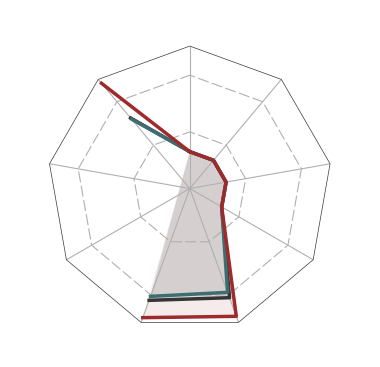

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mae_one


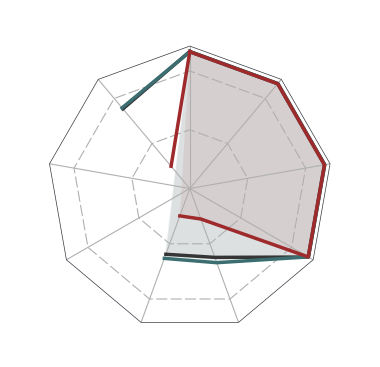

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mape_one


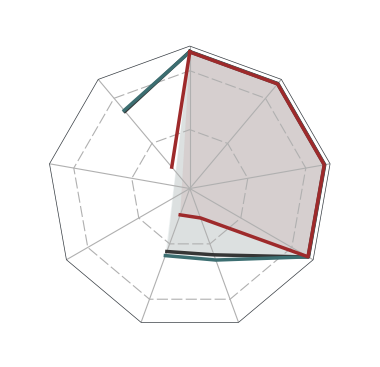

r2_two


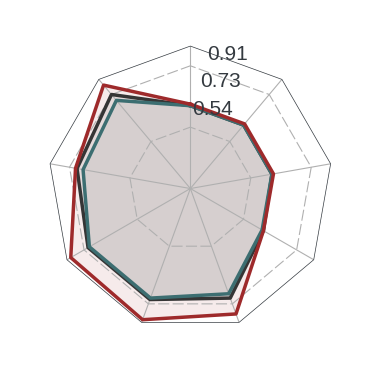

mae_two


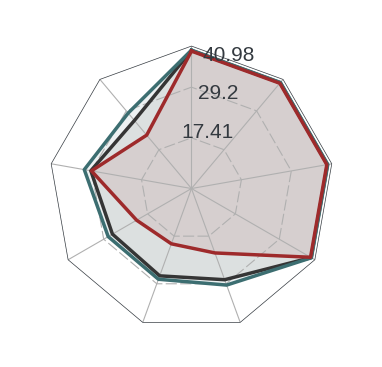

mape_two


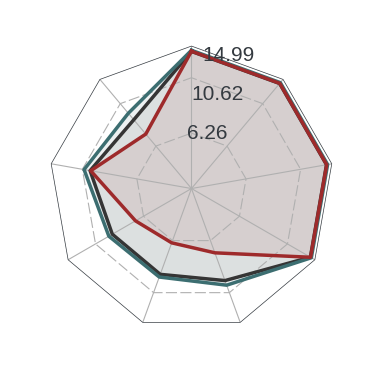

r2_three


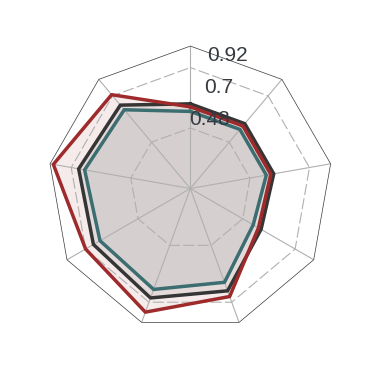

mae_three


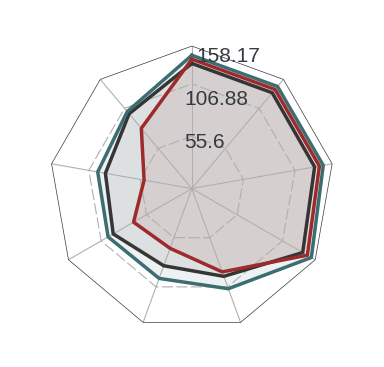

mape_three


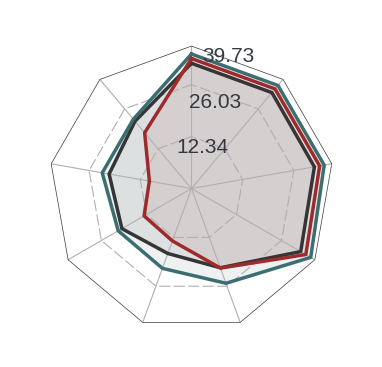

In [54]:
train_col ='#9e2a2b'
val_col  ='#3c6e71'
test_col  ='#353535'

for plant_no in ['one', 'two', 'three']:
    if plant_no == 'one':
        df = df_plant1.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'nox') 
    elif plant_no == 'two':
        df = df_plant2.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'nox')  

    elif plant_no == 'three':
        df = df_plant3.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'nox')  

# CO benchmark

In [39]:
columns=['model', 'train', 'val', 'test']
plant1 = {'model' : ['Linear regression',       'Lasso',      'Ridge',        'Elastic net',      'Random forest',      'XGBoost',            'SVR',                'GPR',                'NN' ],
        'train' :train_plant_1_co ,
        'val' :  val_plant_1_co ,
        'test' :test_plant_1_co  
}

plant2 = {'model' : ['Linear regression',       'Lasso',      'Ridge',        'Elastic net',      'Random forest',      'XGBoost',            'SVR',                'GPR',                'NN' ],
        'train' :train_plant_4 ,
        'val' : val_plant_4 ,
        'test' :test_plant_4
}

df_plant1 = pd.DataFrame(plant1, columns = columns)  
df_plant2 = pd.DataFrame(plant2, columns = columns)
# desired_order = ['Linear regression', 'NN', 'GPR', 'SVR', 'XGBoost', 'Random forest', 'Elastic net', 'Ridge', 'Lasso']
metric =  ['r2', 'mae', 'mape']

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


r2_one


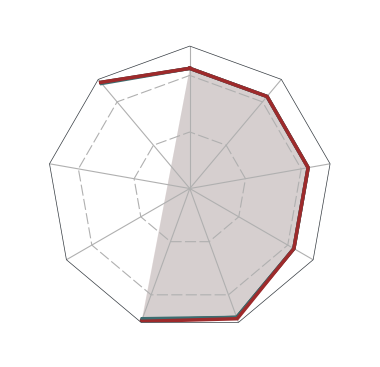

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mae_one


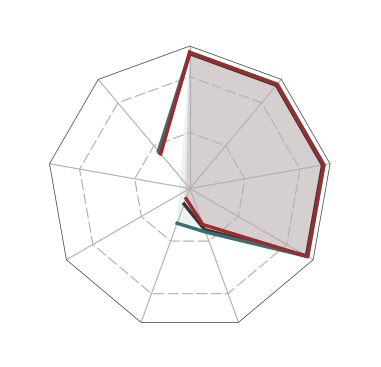

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mape_one


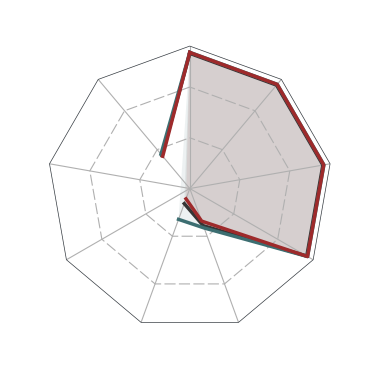

r2_four


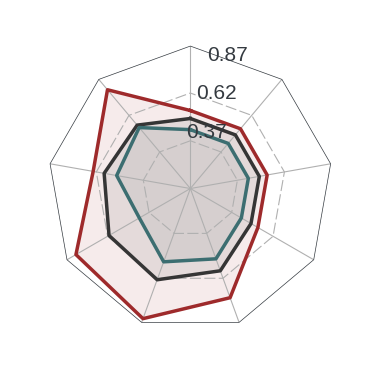

mae_four


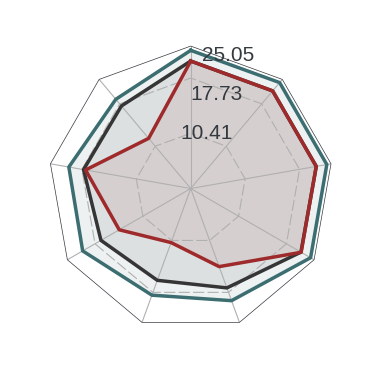

mape_four


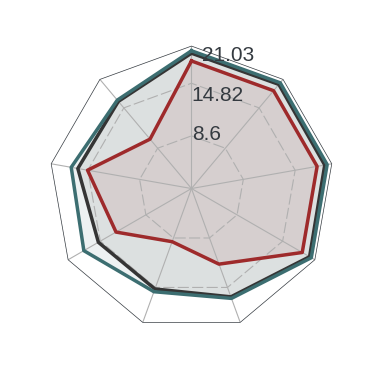

In [40]:
train_col ='#9e2a2b'
val_col  ='#3c6e71'
test_col  ='#353535'

for plant_no in ['one', 'four']:
    if plant_no == 'one':
        df = df_plant1.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'co') 

    elif plant_no == 'four':
        df = df_plant2.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'co')  

# Values for radar (NOx)

In [22]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_1_nox)):
    r2.append([train_plant_1_nox[i][0], val_plant_1_nox[i][0], test_plant_1_nox[i][0]])
    mae.append([train_plant_1_nox[i][1], val_plant_1_nox[i][1], test_plant_1_nox[i][1]])
    mape.append([train_plant_1_nox[i][2], val_plant_1_nox[i][2], test_plant_1_nox[i][2]])
r2 
mae 
mape 

[[0.26, 0.26, 0.26],
 [0.26, 0.26, 0.26],
 [0.26, 0.26, 0.26],
 [0.26, 0.26, 0.26],
 [0.96, 0.78, 0.82],
 [0.97, 0.81, 0.84],
 [nan, nan, nan],
 [nan, nan, nan],
 [0.97, 0.64, 0.65]]

[[34.89, 34.9, 34.97],
 [34.89, 34.9, 34.97],
 [34.89, 34.9, 34.97],
 [34.89, 34.9, 34.97],
 [8.28, 20.14, 18.7],
 [7.43, 18.97, 17.85],
 [nan, nan, nan],
 [nan, nan, nan],
 [7.43, 26.87, 26.53]]

[[11.59, 11.6, 11.63],
 [11.59, 11.6, 11.63],
 [11.59, 11.6, 11.63],
 [11.59, 11.6, 11.63],
 [2.66, 6.46, 5.99],
 [2.38, 6.06, 5.69],
 [nan, nan, nan],
 [nan, nan, nan],
 [2.38, 8.66, 8.56]]

In [23]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_2)):
    r2.append([train_plant_2[i][0], val_plant_2[i][0], test_plant_2[i][0]])
    mae.append([train_plant_2[i][1], val_plant_2[i][1], test_plant_2[i][1]])
    mape.append([train_plant_2[i][2], val_plant_2[i][2], test_plant_2[i][2]])
r2 
mae 
mape 

[[0.55, 0.54, 0.54],
 [0.55, 0.54, 0.54],
 [0.55, 0.54, 0.54],
 [0.55, 0.54, 0.55],
 [0.87, 0.73, 0.76],
 [0.91, 0.76, 0.77],
 [0.9, 0.76, 0.77],
 [0.76, 0.71, 0.75],
 [0.88, 0.75, 0.8]]

[[40.67, 40.96, 40.86],
 [40.67, 40.96, 40.86],
 [40.67, 40.96, 40.86],
 [40.69, 40.98, 40.89],
 [20.29, 30.41, 28.72],
 [17.41, 28.58, 27.5],
 [18.75, 28.46, 27.01],
 [30.06, 32.21, 30.25],
 [20.63, 29.15, 26.28]]

[[14.87, 14.97, 14.85],
 [14.87, 14.97, 14.85],
 [14.87, 14.97, 14.85],
 [14.89, 14.99, 14.87],
 [7.41, 11.14, 10.61],
 [6.26, 10.2, 9.89],
 [7.0, 10.33, 9.9],
 [11.08, 11.81, 11.15],
 [7.7, 10.64, 9.72]]

In [24]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_1_nox)):
    r2.append([train_plant_3[i][0], val_plant_3[i][0],   test_plant_3[i][0]])
    mae.append([train_plant_3[i][1], val_plant_3[i][1],  test_plant_3[i][1]])
    mape.append([train_plant_3[i][2], val_plant_3[i][2], test_plant_3[i][2]])
r2 
mae 
mape 

[[0.54, 0.51, 0.56],
 [0.54, 0.51, 0.56],
 [0.54, 0.51, 0.56],
 [0.52, 0.48, 0.54],
 [0.76, 0.66, 0.72],
 [0.87, 0.71, 0.77],
 [0.8, 0.69, 0.74],
 [0.92, 0.71, 0.75],
 [0.81, 0.68, 0.72]]

[[148.28, 152.74, 143.38],
 [148.28, 152.73, 143.33],
 [148.47, 152.95, 142.93],
 [152.89, 158.17, 146.75],
 [101.72, 122.23, 107.14],
 [72.96, 109.64, 94.2],
 [77.12, 110.87, 104.08],
 [55.6, 109.58, 100.64],
 [90.11, 115.17, 111.89]]

[[37.51, 38.81, 36.13],
 [37.51, 38.81, 36.12],
 [37.56, 38.88, 36.01],
 [38.09, 39.73, 36.39],
 [24.43, 29.09, 24.33],
 [16.09, 24.51, 19.95],
 [15.79, 24.4, 23.17],
 [12.34, 26.14, 24.13],
 [21.02, 26.1, 25.35]]

# Values for radar (CO)

In [25]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_1_co)):
    r2.append([train_plant_1_co[i][0], val_plant_1_co[i][0], test_plant_1_co[i][0]])
    mae.append([train_plant_1_co[i][1], val_plant_1_co[i][1], test_plant_1_co[i][1]])
    mape.append([train_plant_1_co[i][2], val_plant_1_co[i][2], test_plant_1_co[i][2]])
r2 
mae 
mape 

[[0.85, 0.85, 0.85],
 [0.85, 0.85, 0.85],
 [0.85, 0.85, 0.85],
 [0.85, 0.85, 0.85],
 [0.98, 0.97, 0.97],
 [1.0, 0.98, 0.99],
 [nan, nan, nan],
 [nan, nan, nan],
 [0.98, 0.97, 0.98]]

[[36.49, 36.52, 36.17],
 [36.46, 36.48, 36.14],
 [36.49, 36.52, 36.17],
 [36.47, 36.5, 36.15],
 [10.3, 12.42, 11.75],
 [2.89, 9.92, 4.45],
 [nan, nan, nan],
 [nan, nan, nan],
 [12.13, 13.11, 12.57]]

[[16.08, 16.1, 15.98],
 [16.07, 16.08, 15.96],
 [16.08, 16.1, 15.98],
 [16.07, 16.08, 15.97],
 [4.1, 4.96, 4.68],
 [1.3, 3.88, 1.9],
 [nan, nan, nan],
 [nan, nan, nan],
 [4.98, 5.3, 5.11]]

In [36]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_1_co)):
    r2.append([train_plant_4[i][0], val_plant_4[i][0], test_plant_4[i][0]])
    mae.append([train_plant_4[i][1], val_plant_4[i][1], test_plant_4[i][1]])
    mape.append([train_plant_4[i][2], val_plant_4[i][2], test_plant_4[i][2]])
r2 
mae 
mape 

[[0.49, 0.37, 0.44],
 [0.49, 0.37, 0.44],
 [0.49, 0.37, 0.44],
 [0.49, 0.37, 0.44],
 [0.73, 0.47, 0.55],
 [0.87, 0.49, 0.61],
 [0.83, 0.37, 0.59],
 [0.62, 0.47, 0.55],
 [0.81, 0.5, 0.52]]

[[23.06, 25.01, 23.08],
 [23.07, 25.03, 23.06],
 [23.06, 25.01, 23.08],
 [23.08, 25.05, 23.03],
 [15.04, 21.6, 19.14],
 [10.41, 20.54, 17.68],
 [14.94, 22.58, 18.76],
 [19.33, 22.4, 19.7],
 [11.85, 21.09, 19.51]]

[[19.39, 20.94, 20.57],
 [19.41, 20.98, 20.66],
 [19.39, 20.94, 20.57],
 [19.44, 21.03, 20.73],
 [12.23, 17.77, 17.52],
 [8.6, 16.69, 16.25],
 [13.24, 18.89, 16.34],
 [16.04, 18.56, 17.54],
 [9.8, 17.54, 17.29]]

# CO2  bechmark

In [5]:
train_plant_1_co2 = [(0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.95, 1.36, 0.55),
 (1.0, 0.45, 0.18),
 (np.NaN, np.NaN, np.NaN),
 (np.NaN, np.NaN, np.NaN),
 (0.96, 1.49, 0.6)]

val_plant_1_co2 = [(0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.92, 1.8, 0.72),
 (0.95, 1.45, 0.58),
  (np.NaN, np.NaN, np.NaN),
 (np.NaN, np.NaN, np.NaN),
 (0.93, 1.7, 0.68)]


test_plant_1_co2 = [(0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.93, 1.68, 0.67),
 (0.96, 1.34, 0.54),
  (np.NaN, np.NaN, np.NaN),
 (np.NaN, np.NaN, np.NaN),
 (0.94, 1.65, 0.66)]

In [6]:
columns=['model', 'train', 'val', 'test']
plant1 = {'model' : ['Linear regression',       'Lasso',      'Ridge',        'Elastic net',      'Random forest',      'XGBoost',            'SVR',                'GPR',                'NN' ],
        'train' :train_plant_1_co2 ,
        'val' :  val_plant_1_co2 ,
        'test' :test_plant_1_co2  
}


df_plant1 = pd.DataFrame(plant1, columns = columns)  
# desired_order = ['Linear regression', 'NN', 'GPR', 'SVR', 'XGBoost', 'Random forest', 'Elastic net', 'Ridge', 'Lasso']
metric =  ['r2', 'mae', 'mape']

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


r2_one


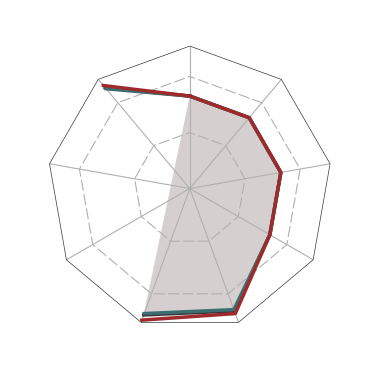

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mae_one


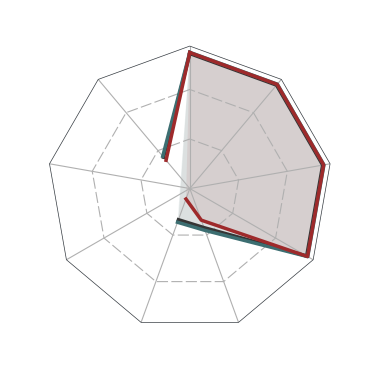

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


mape_one


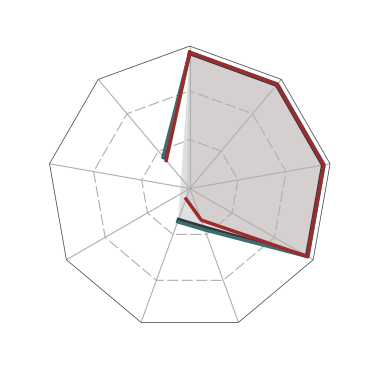

In [14]:
train_col ='#9e2a2b'
val_col  ='#3c6e71'
test_col  ='#353535'

for plant_no in ['one']:
    if plant_no == 'one':
        df = df_plant1.copy()
        for k in range(0,3):
            train_values = [i[k] for i in df['train'].to_list()]  # 0 index for r2 values
            validation_values = [i[k] for i in df['val'].to_list()]
            test_values = [i[k] for i in df['test'].to_list()]
            train_val_test_radar(train_values,validation_values,test_values, f'{metric[k]}_{plant_no}', train_col, val_col, test_col, 'co2') 

In [11]:
r2 = []
mae = []
mape = []

for i in range(len(train_plant_1_co2)):
    r2.append([train_plant_1_co2[i][0], val_plant_1_co2[i][0], test_plant_1_co2[i][0]])
    mae.append([train_plant_1_co2[i][1], val_plant_1_co2[i][1], test_plant_1_co2[i][1]])
    mape.append([train_plant_1_co2[i][2], val_plant_1_co2[i][2], test_plant_1_co2[i][2]])
r2 
mae 
mape 

[[0.66, 0.66, 0.66],
 [0.66, 0.66, 0.66],
 [0.66, 0.66, 0.66],
 [0.66, 0.66, 0.66],
 [0.95, 0.92, 0.93],
 [1.0, 0.95, 0.96],
 [nan, nan, nan],
 [nan, nan, nan],
 [0.96, 0.93, 0.94]]

[[5.49, 5.5, 5.45],
 [5.49, 5.5, 5.45],
 [5.49, 5.5, 5.45],
 [5.49, 5.5, 5.45],
 [1.36, 1.8, 1.68],
 [0.45, 1.45, 1.34],
 [nan, nan, nan],
 [nan, nan, nan],
 [1.49, 1.7, 1.65]]

[[2.23, 2.23, 2.21],
 [2.23, 2.23, 2.21],
 [2.23, 2.23, 2.21],
 [2.23, 2.23, 2.21],
 [0.55, 0.72, 0.67],
 [0.18, 0.58, 0.54],
 [nan, nan, nan],
 [nan, nan, nan],
 [0.6, 0.68, 0.66]]

# Notebook Functions

In [ ]:
def plot_fun_nox(ac, pr, col, label):
    minimum = int(np.min(ac + pr))
    maximum = int(np.max(ac + pr))
    style = 'normal'
    s = 21   #20
    s1 = 16    #13
    w =0.5
    min = minimum
    max = maximum
    marker_size = 26
    fig, ax = plt.subplots(figsize=(4.5,4.5))
        
    _= plt.scatter(ac,pr,color = ['white'] , s=marker_size, linewidth = 2,edgecolors= col, marker = 'o', rasterized=True)
    _= plt.scatter(ac,pr,color = [col] , s=marker_size,alpha = 0.3, marker ='o', rasterized=True )

    _= plt.plot([minimum, minimum],[minimum, minimum], color = 'white', lw = 0)
    _= plt.plot([minimum, maximum],[minimum, maximum], color = 'firebrick', lw = 1.2, ls = '--')

    X = [min, ((min+max)/2),max]
    _= plt.xticks(X,X,rotation = 0, fontweight = style, fontsize = s)
    _= plt.yticks(X, X,rotation = 90, fontweight = style, fontsize = s)
    for label in plt.gca().get_yticklabels():
      label.set_verticalalignment('center')
      
    _= ax.tick_params('both', length=10, width=w, which='major')
    _= ax.tick_params('both', length=5, width=w, which='minor')

    _= plt.xlabel('Measured $NO_{x}$ (PPM)', fontsize= s, fontweight = 'normal')
    _= plt.ylabel('Predicted $NO_{x}$ (PPM)', fontsize= s, fontweight = 'normal')
    
      # inset test
    left, bottom, width, height = [0.16, 0.62, 0.26, 0.26] 
    ax2 = fig.add_axes([left, bottom, width, height])
    p = np.array(ac)
    a = np.array(pr)
    std=np.std(p - a)
    mean=np.mean(p - a)
    xx=mean-2*std
    yy = 0
    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color='white',range = [-4*std, 4*std], rasterized=True )
    rec = patches.Rectangle((xx,yy),4*std, 1.15*find_max(y1), facecolor ='firebrick', alpha = 0.24)
    ax2.add_patch(rec)
    # _= plt.axvline(x = xx, color = 'red', lw =0.6, ls = '--')
    # _= plt.axvline(x = xx+4*std, color = 'red', lw =0.6, ls = '--')

    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color=col,range = [-4*std, 4*std], alpha = 1, ec= 'dimgray', rasterized=True)
    
    ax2.set_ylim(0,find_max(y1)+ 0.15*find_max(y1))
    ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
    xlabel_ax2 = ax2.get_xticklabels()
    ax2.yaxis.tick_right()
    # ax2.yaxis.set_tick_params(labelsize =10,weight = 'normal')
    _= plt.xticks(fontweight = style, fontsize = s1)
    _= plt.yticks(fontweight = style, fontsize = s1, rotation = 90)
    _= ax2.xaxis.set_tick_params(labelsize =s1)  #11.8
    # _= ax2.yaxis.set_tick_params(labelsize =12)
    _= ax2.tick_params('both', length=10, width=w, which='major')
    _= ax2.tick_params('both', length=5, width=w, which='minor')
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel('\u03BD',fontsize=s1, fontweight = style, labelpad = 0)
    ax2.set_xlabel(r'$\epsilon$',fontsize=s1, fontweight = style, labelpad = 0)
    plt.savefig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/nox/parity_{label}.pdf', bbox_inches='tight', transparent = True)
    _=plt.show()


In [73]:
def plot_fun_co(ac, pr, col, label):
    minimum = int(np.min(ac + pr))
    maximum = int(np.max(ac + pr))
    d = 0.4
    style = 'normal'
    s = 21   #20
    s1 = 16    #13
    w =0.5
    min = minimum
    max = maximum
    marker_size = 26
    fig, ax = plt.subplots(figsize=(4.5,4.5))
    _= plt.scatter(ac,pr,color = ['white'] , s=marker_size, linewidth = 2,edgecolors= col, marker = 'o', rasterized=True)
    _= plt.scatter(ac,pr,color = [col] , s=marker_size,alpha = 0.3, marker ='o' , rasterized=True)

    _= plt.plot([minimum, minimum],[minimum, minimum], color = 'white', lw = 0)
    _= plt.plot([minimum, maximum],[minimum, maximum], color = 'firebrick', lw = 1.2, ls = '--')
    X = [min, ((min+max)/2),max]
    _= plt.xticks(X,X,rotation = 0, fontweight = style, fontsize = s)
    _= plt.yticks(X, X,rotation = 90, fontweight = style, fontsize = s)
    for label in plt.gca().get_yticklabels():
        label.set_verticalalignment('center')

    _= ax.tick_params('both', length=10, width=w, which='major')
    _= ax.tick_params('both', length=5, width=w, which='minor')

    _= plt.xlabel('Measured $CO$ (PPM)', fontsize= s, fontweight = 'normal')
    _= plt.ylabel('Predicted $CO$ (PPM)', fontsize= s, fontweight = 'normal')
    
     # inset test
    left, bottom, width, height = [0.16, 0.62, 0.26, 0.26] 
    ax2 = fig.add_axes([left, bottom, width, height])
    p = np.array(ac)
    a = np.array(pr)
    std=np.std(p - a)
    mean=np.mean(p - a)
    xx=mean-2*std
    yy = 0
    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color='white',range = [-4*std, 4*std] , rasterized=True)
    rec = patches.Rectangle((xx,yy),4*std, 1.15*find_max(y1), facecolor ='firebrick', alpha = 0.24)
    ax2.add_patch(rec)

    # _= plt.axvline(x = xx, color = 'red', lw =0.6, ls = '--')
    # _= plt.axvline(x = xx+4*std, color = 'red', lw =0.6, ls = '--')

    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color=col,range = [-4*std, 4*std], alpha = 0.78, ec= 'grey', rasterized=True)
    
    ax2.set_ylim(0,find_max(y1))
    ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
    xlabel_ax2 = ax2.get_xticklabels()
    ax2.yaxis.tick_right()
    # ax2.yaxis.set_tick_params(labelsize =10,weight = 'normal')
    _= plt.xticks(fontweight = style, fontsize = s1)
    _= plt.yticks(fontweight = style, fontsize = s1)
    _= ax2.xaxis.set_tick_params(labelsize =s1)  #11.8
    # _= ax2.yaxis.set_tick_params(labelsize =12)
    _= ax2.tick_params('both', length=10, width=w, which='major')
    _= ax2.tick_params('both', length=5, width=w, which='minor')
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel('\u03BD',fontsize=s1, fontweight = style, labelpad = 0)
    ax2.set_xlabel(r'$\epsilon$',fontsize=s1, fontweight = style, labelpad = 0)
    plt.savefig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co/parity_{label}.pdf', bbox_inches='tight', transparent = True)
    _=plt.show()

# Density plot code (Ravinder)

In [ ]:
train_actual = y_train[list(y_train.columns)[0]].to_list()
test_actual = y_test[list(y_test.columns)[0]].to_list()
test_pred = list(model.predict(X_test))
train_pred = list(model.predict(X_train))
info_ ={
 'scale': 1,   # always =1
 'den_scale_bool': False, #True
 'den_scale': 1   # alywas = 1
  }

# set_font_family(family='Arial')
# set_font_family(family='CMU Serif')
R2_Test = 0.81
R2_Train = 0.97


# y_ac = y_test.values/1000
# y_pr = model.predict(X_test)/1000

y_ac = np.array(test_actual)
y_pr = np.array(test_pred)

info_['margin'] = 0 # margin for range of ploting act vs pred.
rng = [min(y_ac.min(), y_pr.min()) - info_['margin'], max(y_ac.max(), y_pr.max()) + info_['margin']]  # range in which plts show poits, any point outside this considered outlier.
info_['limits'] = rng
info_ ['inter']= 200  # spacing major ticks
info_ ['label']= 'NO$_{x}$ (PPM)'

fig = make_den_plot(info_, y_pr, y_ac, R2_Train, R2_Test) #
# plt.savefig(f"LR_DP.svg", dpi=1200,bbox_inches='tight') #saving file at this path 
plt.show()